<a href="https://colab.research.google.com/github/DnlRKorn/histogram_for_sept26_hackathon/blob/main/make_hist_from_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This needs data available in ./parquet/*.parquet. If those files aren't available first run code in ./make_data.ipynb

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import os
from pathlib import Path
import csv
import pyarrow.parquet as pq
import pandas as pd

In [2]:
!git clone https://github.com/DnlRKorn/histogram_for_sept26_hackathon

Cloning into 'histogram_for_sept26_hackathon'...
remote: Enumerating objects: 100, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 100 (delta 57), reused 75 (delta 43), pack-reused 0 (from 0)
Receiving objects: 100% (100/100), 39.80 MiB | 8.35 MiB/s, done.
Resolving deltas: 100% (57/57), done.
Updating files: 100% (66/66), done.


In [3]:
def pruneOutliers(s:pd.Series,method:str) -> pd.Series:
    if(method=="Keep_Outliers"):return s
    elif(method=="IQR"):
        (q1,q3) = s.quantile([0.25,0.75])
        iqr = abs(q3-q1)
        low_bound = q1 - iqr * 1.5
        up_bound = q3 + iqr * 1.5
        return s[(s>=low_bound) & (s<=up_bound)]
    elif(method=="Z_Score_3stdevs"):
        z_score = s.to_frame().apply(stats.zscore, ddof=1).abs().iloc[:, 0]
        return s[z_score<=3]
    elif(method=="Z_Score_5stdevs"):
        z_score = s.to_frame().apply(stats.zscore, ddof=1).abs().iloc[:, 0]
        return s[z_score<=5]
    else:
        raise ValueError(f"No outlier method {method}")

def plotHistogram(prop_vals:pd.Series, bins, log_y:bool=False, chart_title=""):
    fig, ax = plt.subplots()
    ax.set_title(chart_title)
    ax.hist(prop_vals, bins=bins,log=log_y)

def getSeriesForDataset(dataset):
    pq_path = os.path.join("histogram_for_sept26_hackathon","data","parquet",dataset+".parquet")
    pq_file = pq.ParquetFile(pq_path)
    prop_name = pq_file.schema[5].name
    arr = pq_file.read(columns=[prop_name])
    return arr.to_pandas()[prop_name]

def getDFForDataset(dataset):
    pq_path = os.path.join("histogram_for_sept26_hackathon","data","parquet",dataset+".parquet")
    pq_file = pq.ParquetFile(pq_path)
    prop_name = pq_file.schema[5].name
    #print(pq_file.schema)
    arr = pq_file.read(columns=["sub","pred","qual","obj",prop_name])
    return arr.to_pandas()

def handleCategorical(dataset):
    s = getSeriesForDataset(dataset)
    if(s.dtype=="object"):
      return s.value_counts().reset_index()

def handleInputAndData(dataset,bin_cnt:int,log_bins:bool,log_y:bool, outlier_method:str):
    chart_title = " ".join(dataset.split('-'))

    prop_vals = getSeriesForDataset(dataset)
    prop_vals = pruneOutliers(prop_vals,outlier_method)
    if(log_bins):
        if(prop_vals.min()==0):min_val=0
        else:min_val = np.log10(prop_vals.min())
        bins = np.logspace(min_val,np.log10(prop_vals.max()),bin_cnt)
        print(bins)
    else: #No need to take the bins to log space, just let matplot handle the splitting
        bins = bin_cnt
    plotHistogram(prop_vals,bins,log_y,chart_title)


In [9]:
def addValuesToDf(spqo_df,dataset):
  big_df = getDFForDataset(dataset)
  if(big_df.iloc[:,4].dtype=="object"):
    spqo_df["min"] = np.nan()
    spqo_df["median"] = np.nan()
    spqo_df["max"] = np.nan()
    spqo_df["mean"] = np.nan()
    spqo_df["stdev"] = np.nan()
    return spqo_df

  def getSeriesFromBig(spqo):
      spqo = eval(spqo)
      return big_df[(big_df["sub"]==spqo[0]) & (big_df["pred"]==spqo[1]) & (big_df["qual"]==spqo[2]) & (big_df["obj"]==spqo[3])].iloc[:,4]
  spqo_series = [getSeriesFromBig(spqo) for spqo in spqo_df.spqo]
  spqo_df["min"] = [x.min() for x in spqo_series]
  spqo_df["median"] = [x.quantile(0.5) for x in spqo_series]
  spqo_df["max"] = [x.max() for x in spqo_series]
  spqo_df["mean"] = [x.mean() for x in spqo_series]
  spqo_df["stdev"] = [x.std() for x in spqo_series]
  return spqo_df

def getPresentAbsentCnts(dataset_name,calculate_extra_spqo_stats=False):
    ingest_name,prop = dataset_name.split("-")
    with open("histogram_for_sept26_hackathon/data/prop_seen_absent_cnt.csv") as f:
        dreader = csv.DictReader(f)
        for d in dreader:
            if((d["ingest_name"]==ingest_name) and (d["prop_name"]==prop)):
                s = getSeriesForDataset(dataset_name)
                max_val = s.max()
                min_val = s.min()
                print(f"Data summary for {ingest_name} {prop}\nMinimum Val:{min_val}\nMaximum Val:{max_val}\nPresent Cnt:{d["present_cnt"]}\nAbsent Cnt:{d["absent_cnt"]}")
    df = pd.read_csv(f"histogram_for_sept26_hackathon/data/seen_absent_indiv/{dataset_name}_cnts.csv")
    if(calculate_extra_spqo_stats): df = addValuesToDf(df,dataset_name)
    return df


Data summary for pubtator publications
Minimum Val:1
Maximum Val:27255
Present Cnt:10890003
Absent Cnt:0


,spqo,present_cnt,absent_cnt,min,median,max,mean,stdev
0,"('chemical entity', 'causes', 'n/a', 'disease ...",674002,0,1,1.0,27255,4.494447,53.668025
1,"('chemical entity', 'causes', 'n/a', 'gene or ...",10,0,1,1.0,2,1.200000,0.421637
2,"('chemical entity', 'negatively correlated wit...",519498,0,1,1.0,4056,2.919278,17.014599
3,"('chemical entity', 'negatively correlated wit...",16,0,1,1.0,3,1.187500,0.543906
4,"('chemical entity', 'negatively correlated wit...",795196,0,1,1.0,3326,2.290491,16.508568
5,"('chemical entity', 'pharmacologically interac...",5527,0,1,1.0,33,1.279718,1.288016
6,"('chemical entity', 'pharmacologically interac...",117,0,1,1.0,3,1.085470,0.336633
7,"('chemical entity', 'physically interacts with...",6350,0,1,1.0,109,1.558110,2.760397
8,"('chemical entity', 'physically interacts with...",3,0,1,1.0,1,1.000000,0.000000
9,"('chemical entity', 'physically interacts with...",20999,0,1,1.0,349,2.012715,6.788049


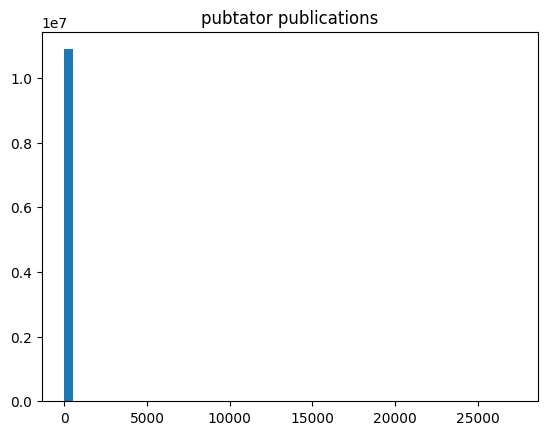

In [11]:
# @title User Input for Histogram Generation {single-column:true}
# @markdown Forms support many types of fields.

num_bins = 50 # @param {type: "number"}
log_bin_size = False # @param {type:"boolean"}
log_bin_height = False # @param {type:"boolean"}
calculate_extra_spqo_stats = True # @param {type:"boolean"}
prune_outlier_method = "Keep_Outliers" # @param ["Keep_Outliers","IQR","Z_Score_3stdevs","Z_Score_5stdevs"]
dataset = "pubtator-publications"  # @param ['alliance-publications', 'bindingdb-publications', 'chembl-has_confidence_score', 'chembl-publications', 'cohd-has_confidence_score', 'ctd-adjusted_p_value', 'ctd-p_value', 'ctd-publications', 'dakp-number_of_cases', 'dakp-publications', 'dgidb-dgidb_evidence_score', 'dgidb-dgidb_interaction_score', 'dgidb-publications', 'diseases-diseases_confidence_score', 'drugcentral-publications', 'gene2phenotype-gene2phenotype_confidence_category', 'gene2phenotype-publications', 'go_cam-publications', 'goa-has_evidence_of_type', 'goa-publications', 'gtopdb-publications', 'hpoa-has_evidence_of_type', 'hpoa-publications', 'intact-publications', 'pubtator-publications', 'semmeddb-publications', 'signor-has_confidence_score', 'signor-publications', 'tmkp-evidence_count', 'tmkp-publications']
# @markdown ---

#print(dataset)
pq_path = os.path.join("histogram_for_sept26_hackathon","data","parquet",dataset+".parquet")
handleInputAndData(dataset,num_bins,log_bin_size,log_bin_height,prune_outlier_method)
getPresentAbsentCnts(dataset,calculate_extra_spqo_stats)
#handleCategorical(dataset)

In [ ]:
#Source | Metric | Edge Type | N | % Missing | Min | P1 | P5 | P10 | P25 | Median | P75 | P90 | P95 | P99 | Max | % Zero | Unique Count | Mean | SD | Skewness

In [98]:
def getPrecentMissing(dataset_name):
    ingest_name,prop = dataset_name.split("-")
    with open("histogram_for_sept26_hackathon/data/prop_seen_absent_cnt.csv") as f:
        for d in csv.DictReader(f):
            if((d["ingest_name"]==ingest_name) and (d["prop_name"]==prop)):
                return (int(d["absent_cnt"])) / (int(d["present_cnt"])+int(d["absent_cnt"]))

def getStatsForSeries(s,source_name,prop_name):
    edge_type = str(s.dtype)
    metric = f"{prop_name} ({edge_type})"
    #print(x,dataset,edge_type,edge_type=="object")
    if(edge_type=="object"):edge_type="str"
    n = s.shape[0]
#    if(s.dtype=="object"):
#      s = s.apply(lambda x:x[0])
    percent_missing = getPrecentMissing(dataset)
    percent_zero = s[s==0].shape[0]/n
    unique_cnt = s.unique().shape[0]
    if(edge_type!="str"):
      (min, p1, p5, p10, p25, median, p75, p90, p95, p99, max) = s.quantile([0,0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1])
      std = s.std()
      skew = s.skew()
      mean = s.mean()
    else:
      (min, p1, p5, p10, p25, median, p75, p90, p95, p99, max) = [None]*11
      std = None
      skew = None
      mean = None
    return (source_name,metric,n,percent_missing,min, p1, p5, p10, p25, median, p75, p90, p95, p99, max, percent_zero, unique_cnt,mean,std,skew)

In [113]:
# @title Big Table of Ingest/Prop Statistics

rows = []
for x in os.listdir("histogram_for_sept26_hackathon/data/parquet"):
  dataset = x.split(".")[0]
  source_name,prop_name = dataset.split('-')
  s = getSeriesForDataset(dataset)
  rows.append(getStatsForSeries(s,source_name,prop_name))
pd.DataFrame(rows,columns=["source","metric (edge_type)","n","percent_missing","min","p1"," 5"," p10","p25","median","p75","p90","p95","p99","max","percent_zero","unique_cnt","mean","std","skew"])

,source,metric (edge_type),n,percent_missing,min,p1,5,p10,p25,median,p75,p90,p95,p99,max,percent_zero,unique_cnt,mean,std,skew
0,hpoa,publications (int32),590486,0.012560,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.600000e+01,0.365026,26,6.821025e-01,6.611446e-01,5.714101
1,goa,publications (int32),2135407,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.645797,2,3.542027e-01,4.782711e-01,0.609685
2,signor,publications (int32),43631,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,8.000000e+00,0.000000,7,1.054800e+00,2.778380e-01,7.092087
3,gtopdb,publications (int32),31883,0.115393,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00,1.700000e+01,0.000000,14,1.281278e+00,8.502352e-01,4.962100
4,ctd,p_value (float32),2282783,0.474602,0.000000,0.000000,0.000000,0.000000,2.802597e-45,4.630000e-26,1.360000e-18,6.120000e-16,3.150000e-15,1.890000e-14,7.170000e-12,0.245871,27103,1.054050e-15,2.189533e-14,0.000000
5,hpoa,has_evidence_of_type (object),262360,0.561269,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3,NaN,NaN,NaN
6,dgidb,dgidb_interaction_score (float32),41832,0.220599,0.000392,0.002528,0.006576,0.011329,2.858916e-02,8.863124e-02,3.575603e-01,1.410913e+00,3.262738e+00,1.305095e+01,1.566114e+02,0.000000,5378,8.392579e-01,4.038159e+00,15.743071
7,gene2phenotype,publications (int32),3022,0.025790,1.000000,1.000000,1.000000,1.000000,1.000000e+00,3.000000e+00,5.000000e+00,1.000000e+01,1.400000e+01,2.800000e+01,8.200000e+01,0.000000,45,4.345467e+00,5.659701e+00,4.416134
8,ctd,adjusted_p_value (float32),2282783,0.474602,0.000000,0.000000,0.000000,0.000000,2.929975e-41,4.290000e-22,1.130000e-14,4.660000e-12,2.330000e-11,7.590000e-11,1.000000e-10,0.220680,29510,3.386696e-12,1.267325e-11,0.000000
9,bindingdb,publications (int32),1361214,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000,1,1.000000e+00,0.000000e+00,0.000000


In [123]:
# @title Make Table of Stats Broken Up By SPO
dataset = "signor-publications"  # @param ['alliance-publications', 'bindingdb-publications', 'chembl-has_confidence_score', 'chembl-publications', 'cohd-has_confidence_score', 'ctd-adjusted_p_value', 'ctd-p_value', 'ctd-publications', 'dakp-number_of_cases', 'dakp-publications', 'dgidb-dgidb_evidence_score', 'dgidb-dgidb_interaction_score', 'dgidb-publications', 'diseases-diseases_confidence_score', 'drugcentral-publications', 'gene2phenotype-gene2phenotype_confidence_category', 'gene2phenotype-publications', 'go_cam-publications', 'goa-has_evidence_of_type', 'goa-publications', 'gtopdb-publications', 'hpoa-has_evidence_of_type', 'hpoa-publications', 'intact-publications', 'pubtator-publications', 'semmeddb-publications', 'signor-has_confidence_score', 'signor-publications', 'tmkp-evidence_count', 'tmkp-publications']

rows = []
#for x in os.listdir("histogram_for_sept26_hackathon/data/parquet"):
source_name,prop_name = dataset.split('-')
df = getDFForDataset(dataset)
for spo_grouped_pd in df.groupby(["sub","pred","obj"]):
  sub,pred,obj = spo_grouped_pd[0]
  s = spo_grouped_pd[1].iloc[:,4]
  (source_name,metric,n,percent_missing,min, p1, p5, p10, p25, median, p75, p90, p95, p99, max, percent_zero, unique_cnt,mean,std,skew) = getStatsForSeries(s,source_name,prop_name)
  rows.append([source_name,f"({sub},{pred},{obj})",sub,pred,obj,metric,n,percent_missing,min, p5, p25, median, p75, p95, max, percent_zero, unique_cnt,mean,std,skew])

pd.DataFrame(rows,columns=["source","SPO","sub","pred","obj","metric (edge_type)","n","percent_missing","min","p5","p25","median","p75","p95","max","percent_zero","unique_cnt","mean","std","skew"])

,source,SPO,sub,pred,obj,metric (edge_type),n,percent_missing,min,p5,p25,median,p75,p95,max,percent_zero,unique_cnt,mean,std,skew
0,signor,"(chemical entity,affects,chemical entity)",chemical entity,affects,chemical entity,publications (int32),413,0.0,1.0,1.0,1.0,1.0,1.0,2.0,6.0,0.0,5,1.082324,0.397812,7.192994
1,signor,"(chemical entity,affects,gene or gene product)",chemical entity,affects,gene or gene product,publications (int32),2335,0.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,0.0,5,1.055246,0.264974,6.072288
2,signor,"(chemical entity,directly physically interacts...",chemical entity,directly physically interacts with,chemical entity,publications (int32),411,0.0,1.0,1.0,1.0,1.0,1.0,2.0,6.0,0.0,5,1.082725,0.398740,7.174948
3,signor,"(chemical entity,directly physically interacts...",chemical entity,directly physically interacts with,gene or gene product,publications (int32),2259,0.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,0.0,5,1.055777,0.267001,6.070379
4,signor,"(gene or gene product,affects,chemical entity)",gene or gene product,affects,chemical entity,publications (int32),72,0.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,2,1.013889,0.117851,8.485281
5,signor,"(gene or gene product,directly physically inte...",gene or gene product,directly physically interacts with,chemical entity,publications (int32),72,0.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,2,1.013889,0.117851,8.485281
6,signor,"(gene or gene product,directly physically inte...",gene or gene product,directly physically interacts with,gene or gene product,publications (int32),17489,0.0,1.0,1.0,1.0,1.0,1.0,1.0,8.0,0.0,7,1.057979,0.285876,6.902794
7,signor,"(gene or gene product,regulates,gene or gene p...",gene or gene product,regulates,gene or gene product,publications (int32),20580,0.0,1.0,1.0,1.0,1.0,1.0,1.0,8.0,0.0,7,1.051118,0.268196,7.331520


In [106]:
sub,pred,obj = spo_grouped_pd[0]

In [55]:
dataset = "ctd-adjusted_p_value"
df = getDFForDataset(dataset)
df

required group field_id=-1 schema {
  optional binary field_id=-1 kgx (String);
  optional binary field_id=-1 sub (String);
  optional binary field_id=-1 pred (String);
  optional binary field_id=-1 qual (String);
  optional binary field_id=-1 obj (String);
  optional float field_id=-1 adjusted_p_value;
  optional boolean field_id=-1 zero_len;
  optional boolean field_id=-1 na_val;
}



,sub,pred,obj,adjusted_p_value
0,chemical entity,associated with,biological process,1.480000e-12
1,chemical entity,associated with,pathway,2.440000e-14
2,chemical entity,associated with,pathway,2.760000e-19
3,chemical entity,associated with,biological process,9.070000e-12
4,chemical entity,associated with,biological process,1.100000e-11
...,...,...,...,...
2282778,chemical entity,associated with,pathway,5.210000e-16
2282779,chemical entity,associated with,pathway,5.210000e-16
2282780,chemical entity,associated with,pathway,1.480000e-14
2282781,chemical entity,associated with,biological process,2.180000e-11


In [64]:

prop_vals = getSeriesForDataset(dataset)
outlier_method = "Keep_Outliers"
log_bins = True
prop_vals = pruneOutliers(prop_vals,outlier_method)
if(log_bins):
    if(prop_vals.min()==0):min_val=0
    else:min_val = np.log10(prop_vals.min())
    bins = np.logspace(min_val,np.log10(prop_vals.max()),20)

In [65]:
bins

array([1.00000000e+00, 2.97635144e-01, 8.85866792e-02, 2.63665090e-02,
       7.84759973e-03, 2.33572148e-03, 6.95192799e-04, 2.06913809e-04,
       6.15848215e-05, 1.83298072e-05, 5.45559482e-06, 1.62377675e-06,
       4.83293028e-07, 1.43844990e-07, 4.28133244e-08, 1.27427500e-08,
       3.79269023e-09, 1.12883791e-09, 3.35981833e-10, 1.00000001e-10])

Data summary for pubtator publications
Minimum Val:1
Maximum Val:27255
Present Cnt:10890003
Absent Cnt:0


KeyboardInterrupt: 

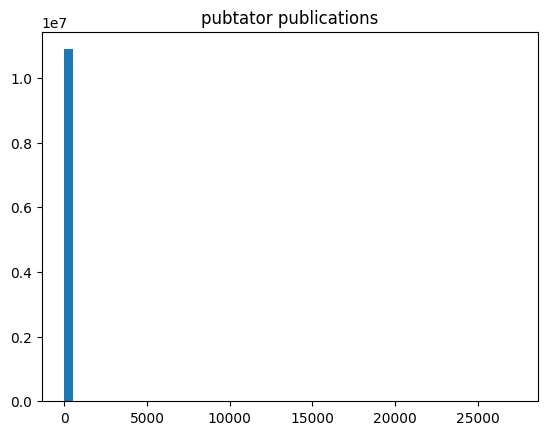

In [12]:
# @title User Input for Histogram Generation {single-column:true}
# @markdown Forms support many types of fields.

num_bins = 50 # @param {type: "number"}
spqo0 = False # @param {type:"boolean"}
spqo1 = False # @param {type:"boolean"}
spqo2 = False # @param {type:"boolean"}
spqo3 = False # @param {type:"boolean"}
spqo4 = False # @param {type:"boolean"}
spqo5 = False # @param {type:"boolean"}
spqo6 = False # @param {type:"boolean"}
spqo7 = False # @param {type:"boolean"}
spqo8 = False # @param {type:"boolean"}
spqo9 = False # @param {type:"boolean"}
spqo10 = False # @param {type:"boolean"}
spqo11 = False # @param {type:"boolean"}
spqo12 = False # @param {type:"boolean"}
spqo13 = False # @param {type:"boolean"}
spqo14 = False # @param {type:"boolean"}
spqo15 = False # @param {type:"boolean"}
spqo16 = False # @param {type:"boolean"}
spqo17 = False # @param {type:"boolean"}
spqo18 = False # @param {type:"boolean"}
spqo19 = False # @param {type:"boolean"}
spqo20 = False # @param {type:"boolean"}
spqo21 = False # @param {type:"boolean"}
spqo22 = False # @param {type:"boolean"}
spqo23 = False # @param {type:"boolean"}
spqo24 = False # @param {type:"boolean"}
spqo25 = False # @param {type:"boolean"}
spqo26 = False # @param {type:"boolean"}
spqo27 = False # @param {type:"boolean"}
spqo28 = False # @param {type:"boolean"}
spqo29 = False # @param {type:"boolean"}
spqo30 = False # @param {type:"boolean"}
spqo31 = False # @param {type:"boolean"}
spqo32 = False # @param {type:"boolean"}
spqo33 = False # @param {type:"boolean"}
spqo34 = False # @param {type:"boolean"}
spqo35 = False # @param {type:"boolean"}
spqo36 = False # @param {type:"boolean"}
spqo37 = False # @param {type:"boolean"}
spqo38 = False # @param {type:"boolean"}
spqo39 = False # @param {type:"boolean"}
log_bin_size = False # @param {type:"boolean"}
log_bin_height = False # @param {type:"boolean"}
calculate_extra_spqo_stats = False # @param {type:"boolean"}
prune_outlier_method = "Keep_Outliers" # @param ["Keep_Outliers","IQR","Z_Score_3stdevs","Z_Score_5stdevs"]
dataset = "pubtator-publications"  # @param ['alliance-publications', 'bindingdb-publications', 'chembl-has_confidence_score', 'chembl-publications', 'cohd-has_confidence_score', 'ctd-adjusted_p_value', 'ctd-p_value', 'ctd-publications', 'dakp-number_of_cases', 'dakp-publications', 'dgidb-dgidb_evidence_score', 'dgidb-dgidb_interaction_score', 'dgidb-publications', 'diseases-diseases_confidence_score', 'drugcentral-publications', 'gene2phenotype-gene2phenotype_confidence_category', 'gene2phenotype-publications', 'go_cam-publications', 'goa-has_evidence_of_type', 'goa-publications', 'gtopdb-publications', 'hpoa-has_evidence_of_type', 'hpoa-publications', 'intact-publications', 'pubtator-publications', 'semmeddb-publications', 'signor-has_confidence_score', 'signor-publications', 'tmkp-evidence_count', 'tmkp-publications']
# @markdown ---

#print(dataset)
pq_path = os.path.join("histogram_for_sept26_hackathon","data","parquet",dataset+".parquet")
handleInputAndData(dataset,num_bins,log_bin_size,log_bin_height,prune_outlier_method)
getPresentAbsentCnts(dataset,calculate_extra_spqo_stats)
#handleCategorical(dataset)

In [26]:
for i in range(40):
  print(f"spqo{i} = False # @param "+'{type:"boolean"}')


spqo0 = False # @param {type:"boolean"}
spqo1 = False # @param {type:"boolean"}
spqo2 = False # @param {type:"boolean"}
spqo3 = False # @param {type:"boolean"}
spqo4 = False # @param {type:"boolean"}
spqo5 = False # @param {type:"boolean"}
spqo6 = False # @param {type:"boolean"}
spqo7 = False # @param {type:"boolean"}
spqo8 = False # @param {type:"boolean"}
spqo9 = False # @param {type:"boolean"}
spqo10 = False # @param {type:"boolean"}
spqo11 = False # @param {type:"boolean"}
spqo12 = False # @param {type:"boolean"}
spqo13 = False # @param {type:"boolean"}
spqo14 = False # @param {type:"boolean"}
spqo15 = False # @param {type:"boolean"}
spqo16 = False # @param {type:"boolean"}
spqo17 = False # @param {type:"boolean"}
spqo18 = False # @param {type:"boolean"}
spqo19 = False # @param {type:"boolean"}
spqo20 = False # @param {type:"boolean"}
spqo21 = False # @param {type:"boolean"}
spqo22 = False # @param {type:"boolean"}
spqo23 = False # @param {type:"boolean"}
spqo24 = False # @param {t